In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib import font_manager
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3

# Figure 2A

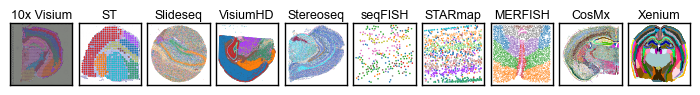

In [ ]:
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(1, 10, figsize=(width_inch, height_inch), sharey=False)
data_dic = {'10x Visium': 'Mouse_Brain_Section_Coronal_data',
            'ST': 'processed/Mouse Brain_20A_data',
            'Slideseq': 'process/Brain/Mouse_Cortex_data_processed',
            'VisiumHD': 'Mouse_Brain/Mouse_Brain_FixedForzen_raw',
            'Stereoseq': 'processed/Mouse Hemi-Brain_Cell_Bin_Data_Whole_data',
            'seqFISH': 'precessed/OB_View0',
            'STARmap': 'processed/Mouse Visual Cortex_20180410_BY3_1kgenes_data',
            'MERFISH':'processed/Hypothalamus_Animal1_Bregma-0.04_domain',
            'CosMx':'Mouse_Brain/Mouse_Brain_Hemisphere_full',
            'Xenium':'Mouse_Brain/Mouse_Brain_MultiSection1_annotation',
           }
row = 0
col = 0
for col, (technology, sample) in enumerate(data_dic.items()):
    h5ad_path = f"dataset/{technology}/{sample}.h5ad"
    adata = sc.read(h5ad_path)
    if technology == '10x Visium':
        sc.pl.spatial(adata, color=['ground_truth'], show=False, ax=axes[col], legend_loc=None)
    elif technology == 'ST':
        sc.pl.spatial(adata, color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=5)
    elif technology == 'STARmap':
        sc.pl.embedding(adata, basis='spatial', color=['celltype'], show=False, ax=axes[col], legend_loc=None, size=5)    
    elif technology == 'seqFISH':
        sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=5)    
    elif technology == 'MERFISH':
        sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=1)    
    else:
        sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=0.2)
    axes[col].set_title(technology, fontsize=9, pad=3)
    axes[col].set_box_aspect(1)
    axes[col].set_xlabel('') 
    axes[col].set_ylabel('') 
    col += 1
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
plt.show()

# Figure 2B

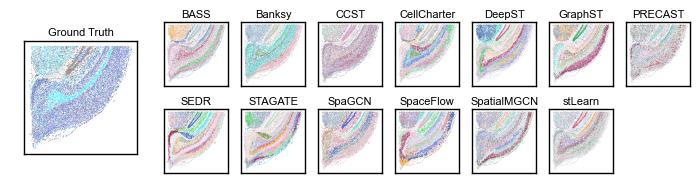

In [9]:
width_inch = 18 / 2.54
height_inch = 2.4 / 2.54
fig, axes = plt.subplots(2, 9, figsize=(width_inch, height_inch*2), sharey=False)
technology = 'Stereoseq'
dataset = 'Mouse Hemi-Brain'
sample = 'Cell_Bin_Data_Whole_sub1'
Methods = ['BASS', 'Banksy', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'STAGATE', 'SpaGCN', 'SpaceFlow', 'SpatialMGCN', 'stLearn']
for row in range(2):
    for col in range(2):
        axes[row, col].remove()
big_ax = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
data_dir = f"dataset/{technology}/processed"
result_dir = f"Outputs/{technology}/"
raw_adata = sc.read(f"{data_dir}/{dataset}_{sample}_data.h5ad")
adata = raw_adata.copy()
inset_ax = big_ax.inset_axes([0.1, 0.1, 0.8, 0.8])
sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=inset_ax, legend_loc=None, size=0.6)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Ground Truth', fontsize=8, pad=4)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['ground_truth'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=5, label=label)
    for label in labels
]
big_ax.set_box_aspect(1)
big_ax.set_xlabel('')
big_ax.set_ylabel('')
big_ax.set_title('')
big_ax.set_xticks([])
big_ax.set_yticks([])
for spine in big_ax.spines.values():
    spine.set_visible(False)

for row in range(2):
    for col in range(2, 9):  
        if (row * 7 + (col - 2)) > 12:
            break
        method_index = row * 7 + (col - 2)
        method = Methods[method_index]
   
        result_obs = pd.read_csv(f"{result_dir}/rep_1/{sample}_{method}_obs.csv", index_col = 0)
        adata = raw_adata.copy()
        adata.obs = adata.obs.join(result_obs[['predict_cluster']], how='left')
        adata = adata[~pd.isnull(adata.obs['predict_cluster'])]
        adata.obs['predict_cluster'] = adata.obs['predict_cluster'].astype('category') 
        ax = axes[row, col]
        sc.pl.embedding(
            adata,
            basis='spatial',
            color='predict_cluster',
            show=False,
            ax=ax,
            legend_loc=None,
            size=0.2
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_box_aspect(1)
        ax.set_title(method, fontsize=8, pad=3)
        for spine in ax.spines.values():
            #spine.set_linewidth(0.5)
            spine.set_color('black')
for ax_row in axes:
    for ax in ax_row:
        if ax and not ax.has_data():
            try:
                ax.remove() 
            except KeyError:
                pass
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.2, hspace=0.05)
#plt.savefig("splot/Sample_Stereoseq2.pdf")
plt.show()

# Figure 2C

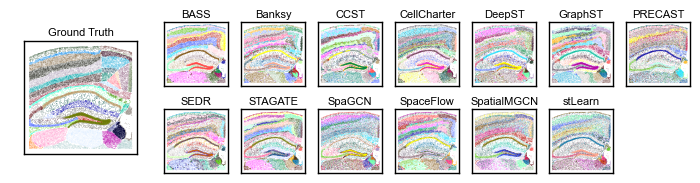

In [10]:
width_inch = 18 / 2.54
height_inch = 2.4 / 2.54
fig, axes = plt.subplots(2, 9, figsize=(width_inch, height_inch*2), sharey=False)
technology = 'Xenium'
dataset = 'Mouse_Brain'
sample = 'Mouse_Brain_MultiSection1_sub4'
Methods = ['BASS', 'Banksy', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'STAGATE', 'SpaGCN', 'SpaceFlow', 'SpatialMGCN', 'stLearn']
for row in range(2):
    for col in range(2):
        axes[row, col].remove()
big_ax = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
data_dir = f"dataset/{technology}"
result_dir = f"Outputs/{technology}/"
raw_adata = sc.read(f"{data_dir}/{dataset}/{sample}.h5ad")
adata = raw_adata.copy()
inset_ax = big_ax.inset_axes([0.1, 0.1, 0.8, 0.8])
sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=inset_ax, legend_loc=None, size=0.6)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Ground Truth', fontsize=8, pad=4)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['ground_truth'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=5, label=label)
    for label in labels
]
big_ax.set_box_aspect(1)
big_ax.set_xlabel('')
big_ax.set_ylabel('')
big_ax.set_title('')
big_ax.set_xticks([])
big_ax.set_yticks([])
for spine in big_ax.spines.values():
    spine.set_visible(False)

for row in range(2):
    for col in range(2, 9):  
        if (row * 7 + (col - 2)) > 12:
            break
        method_index = row * 7 + (col - 2)
        method = Methods[method_index]
   
        result_obs = pd.read_csv(f"{result_dir}/rep_1/{sample}_{method}_obs.csv", index_col = 0)
        result_obs.index = result_obs.index.astype(str)
        adata = raw_adata.copy()
        adata.obs = adata.obs.join(result_obs[['predict_cluster']], how='left')
        adata = adata[~pd.isnull(adata.obs['predict_cluster'])]
        adata.obs['predict_cluster'] = adata.obs['predict_cluster'].astype('category') 
        ax = axes[row, col]
        sc.pl.embedding(
            adata,
            basis='spatial',
            color='predict_cluster',
            show=False,
            ax=ax,
            legend_loc=None,
            size=0.2
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_box_aspect(1)
        ax.set_title(method, fontsize=8, pad=3)
        for spine in ax.spines.values():
            #spine.set_linewidth(0.5)
            spine.set_color('black')
for ax_row in axes:
    for ax in ax_row:
        if ax and not ax.has_data():
            try:
                ax.remove() 
            except KeyError:
                pass
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.2, hspace=0.05)
#plt.savefig("splot/Sample_Xenium.pdf")
plt.show()

# Figure 2D

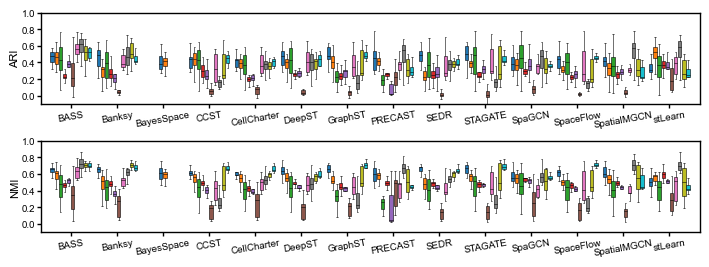

In [11]:
df_all = pd.read_csv("df/Result_df_all.csv", index_col=0)
methods = sorted(list(set(df_all['Method'])))
technologys = ['10x Visium','ST','Slideseq','VisiumHD','Stereoseq','seqFISH','STARmap','MERFISH','CosMx','Xenium']
metrics = ['ARI', 'NMI']
technology_order= ['10x Visium','ST','Slideseq','VisiumHD','Stereoseq','seqFISH','STARmap','MERFISH','CosMx','Xenium']
df_all['Technology'] = pd.Categorical(df_all['Technology'], categories=technology_order, ordered=True)
method_order = ['Banksy', 'BASS', 'BayesSpace', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'SpaceFlow', 'SpaGCN', 'SpatialMGCN', 'STAGATE', 'stLearn']
df_all['Method'] = pd.Categorical(df_all['Method'], categories=method_order, ordered=True)
technology_colors = {
    '10x Visium': '#1F77B4', 
    'ST': '#FF7F0E',
    'Slideseq': '#2CA02C',
    'VisiumHD': '#D62728',
    'Stereoseq': '#9467BD',
    'seqFISH': '#8C564B',
    'STARmap': '#E377C2',
    'MERFISH': '#7F7F7F',
    'CosMx': '#BCBD22',
    'Xenium': '#17BECF'
}

# Matplotlib styling
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
sns.set(style="ticks") 

# Plotting with manual box placement
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(2, 1, figsize=(width_inch, 2 * height_inch), sharey=False)

# Plotting parameters
box_width = 0.14
gap = 0.04
method_spacing = 2  
method_positions = np.arange(len(methods)) * method_spacing

for ax, metric in zip(axes, metrics):
    for j, method in enumerate(methods):
        method_techs = df_all[df_all['Method'] == method]['Technology'].dropna().unique()
        method_techs = [tech for tech in technology_order if tech in method_techs]
        n_techs = len(method_techs)

        for i, technology in enumerate(method_techs):
            offset = (i - (n_techs - 1) / 2) * (box_width + gap)
            position = method_positions[j] + offset

            subset = df_all[(df_all['Method'] == method) & (df_all['Technology'] == technology)][metric]
            bplot = ax.boxplot(subset,
                               positions=[position],
                               widths=box_width,
                               patch_artist=True,
                               showfliers=False,
                               boxprops=dict(facecolor=technology_colors[technology],
                                             edgecolor='black', linewidth=0.4),
                               medianprops=dict(color='black', linewidth=0.4),
                               whiskerprops=dict(color='black', linewidth=0.4),
                               capprops=dict(color='black', linewidth=0.4))

    ax.set_xticks(method_positions)
    #ax.set_xticklabels(methods, rotation=10, ha='right', fontsize=7)
    ax.set_xticklabels(methods, rotation=10, fontsize=7)
    ax.set_ylabel(metric, fontsize=8, labelpad=1, color='black')
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_ylim(-0.1, 1)
    ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=3, width=1, color='black', labelcolor='black')
    ax.grid(False)
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1)
        ax.spines[spine].set_color('black')
# Adjust layout
plt.subplots_adjust(left=0.05, right=0.98, top=0.98, bottom=0.05, hspace=0.4)
#plt.savefig("Figure2D.pdf")
plt.show()

# Figure 2E

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

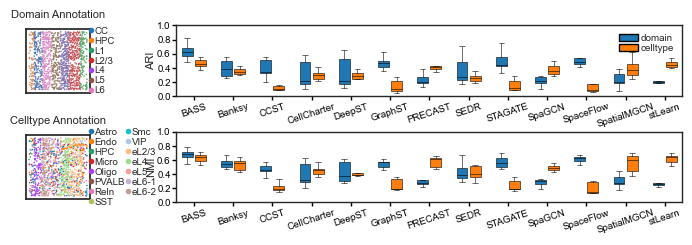

In [15]:
df_subset = pd.read_csv("df/Result_df_sub.csv", index_col=0)
methods = sorted(list(set(df_subset['Method'])))
metrics = ['ARI', 'NMI']
group_order= ['domain','celltype']
df_subset['Level'] = pd.Categorical(df_subset['Level'], categories=group_order, ordered=True)
method_order = ['Banksy', 'BASS', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'SpaceFlow', 'SpaGCN', 'SpatialMGCN', 'STAGATE', 'stLearn']
df_subset['Method'] = pd.Categorical(df_subset['Method'], categories=method_order, ordered=True)
group_color = {
    'domain': '#1F77B4',     
    'celltype': '#FF7F0E'    
}

width_inch = 18 / 2.54
height_inch = 6 / 2.54
fig = plt.figure(figsize=(width_inch, height_inch))
gs = gridspec.GridSpec(2, 5, figure=fig, width_ratios=[1.4, 1, 1, 1, 1], height_ratios=[1, 1], wspace=0.6, hspace=0.5)

row = 0
ax = fig.add_subplot(gs[row, 0])
inset_ax = ax.inset_axes([0, 0.05, 0.9, 0.9])
adata = sc.read("dataset/STARmap/processed/Mouse Visual Cortex_20180505_BY3_1kgenes_data.h5ad")
sc.pl.embedding(adata, basis='spatial', color=['domain'], show=False, ax=inset_ax, legend_loc=None, size=5)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Domain Annotation', fontsize=8, pad=8)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['domain'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=4, label=label)
    for label in labels
]
ax.legend(handles=legend_elements,loc='center left',bbox_to_anchor=(0.8, 0.5),ncol=1,frameon=False,fontsize=7,title_fontsize=7,labelspacing=0.1,handlelength=0.6,handletextpad=0.1,borderpad=0,columnspacing=0.01)
ax.set_box_aspect(1)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
row = 1
ax = fig.add_subplot(gs[row, 0])
inset_ax = ax.inset_axes([0, 0.05, 0.9, 0.9])
adata = sc.read("dataset/STARmap/processed/Mouse Visual Cortex_20180505_BY3_1kgenes_data.h5ad")
sc.pl.embedding(adata, basis='spatial', color=['celltype'], show=False, ax=inset_ax, legend_loc=None, size=5)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Celltype Annotation', fontsize=8, pad=8)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['celltype'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=4, label=label)
    for label in labels
]
ax.legend(handles=legend_elements,loc='center left',bbox_to_anchor=(0.8, 0.5),ncol=2,frameon=False,
          fontsize=7,title_fontsize=7,labelspacing=0.1,handlelength=0.6,handletextpad=0.1,borderpad=0,columnspacing=0.01)
ax.set_box_aspect(1)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
legend_elements = [
    Patch(facecolor=group_color[group], edgecolor='black', label=group)
    for group in group_order
]
for row in range(2):
    ax = fig.add_subplot(gs[row, 1:])
    metric = metrics[row]

    box_width = 0.5
    gap = 0.1
    method_spacing = 1.8  
    method_positions = np.arange(len(methods)) * method_spacing

    for j, method in enumerate(methods):
        center = method_positions[j]
        num_groups = len(group_order)
        for i, group in enumerate(group_order):
            offset = (i - 0.5) * (box_width + gap)
            position = center + offset
            subset = df_subset[(df_subset['Method'] == method) & (df_subset['Level'] == group)][metric]

            bplot = ax.boxplot(subset,
                               positions=[position],
                               widths=box_width,
                               patch_artist=True,
                               showfliers=False,
                               boxprops=dict(facecolor=group_color[group], linewidth=0.4),
                               medianprops=dict(color='black', linewidth=0.4),
                               whiskerprops=dict(linewidth=0.4),
                               capprops=dict(linewidth=0.4)
                              )

    ax.set_xticks(method_positions)
    ax.set_xticklabels(methods, rotation=18, fontsize=7)
    ax.set_ylabel(metric, fontsize=8, labelpad=1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_ylim(0, 1)
    ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=3, width=1, color='black', labelcolor='black')
    ax.grid(False)
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1)
    if row == 0:
        ax.legend(handles=legend_elements, loc='upper right', fontsize=7, frameon=False, labelspacing=0.1, handletextpad=0.2)
plt.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.15, hspace=0.4)
#plt.savefig("Figure2E.pdf")
plt.show()